# Notebook 02 - PCA Fault Detection

**Model:** Principal Component Analysis (PCA) -- unsupervised anomaly detection

**Task:** Detect whether a sample deviates from normal plant operation (binary: normal vs. fault)

**Approach:**
1. PCA is fitted on fault-free training data only -- it learns a compact model of what normal operation looks like
2. For any new sample, two statistics are computed to measure how much the sample deviates from that normal model:
   - **T² (Hotelling):** Measures deviation *within* the PCA subspace -- captures faults that amplify normal operating patterns
   - **Q (SPE):** Measures reconstruction error -- captures faults that introduce patterns not seen in normal data
3. A sample is flagged as a fault if **Q > threshold OR T² > threshold** (either detector is sufficient)
4. Thresholds are set analytically at 99% confidence using the fault-free training distribution

**Data:** Pre-scaled and pre-processed parquets from Notebook 01 (StandardScaler fitted on fault-free training data)

**Fault classes:** 17 fault classes (0 = normal + faults 1, 2, 4--8, 10--14, 16--20). Faults 3, 9, 15 excluded -- their signatures overlap substantially with normal operation and are undetectable by linear PCA (Shams et al., 2010).

## Section 1 - Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_parquet('../data/processed/train_processed.parquet')
test_df  = pd.read_parquet('../data/processed/test_processed.parquet')

meta_cols    = ['faultNumber', 'simulationRun', 'sample', 'run_id']
feature_cols = [c for c in train_df.columns if c not in meta_cols]

print(f'Training: {len(train_df):,} rows x {len(feature_cols)} features')
print(f'Test:     {len(test_df):,} rows x {len(feature_cols)} features')
print(f'Fault classes: {sorted(train_df["faultNumber"].unique())}')
print(f'run_id sample: {train_df["run_id"].iloc[0]}')

Training: 4,330,000 rows x 48 features
Test:     7,280,000 rows x 48 features
Fault classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
run_id sample: 0_1


## Section 2 - PCA Model

PCA is fitted on fault-free training data only. Data is already StandardScaled from notebook 01. The number of components is selected automatically to capture 90% of variance.

The eigenvectors (P) and eigenvalues (L) are extracted directly from the fitted PCA object -- these are used in Sections 3 and 4 to compute T2 and Q statistics without going through sklearn's transform API.

In [2]:
from sklearn.decomposition import PCA

# Fault-free training data only (already StandardScaled)
ff_train = train_df[train_df['faultNumber'] == 0][feature_cols].values

# Find number of components needed to reach 90% variance
_pca_full = PCA().fit(ff_train)
N_COMPONENTS = int(np.argmax(np.cumsum(_pca_full.explained_variance_ratio_) >= 0.90)) + 1

pca = PCA(n_components=N_COMPONENTS)
pca.fit(ff_train)

cum_var = np.sum(pca.explained_variance_ratio_)
print(f'Components:                  {N_COMPONENTS}')
print(f'Cumulative variance explained: {cum_var:.4f}')
print(f'Input feature count:         {len(feature_cols)}')
print(f'Fault-free training samples: {len(ff_train):,}')

# Eigenvectors and eigenvalues for manual T2 / Q computation
P = pca.components_.T        # shape: (n_features, n_components)
L = pca.explained_variance_  # eigenvalues, shape: (n_components,)
print(f'\nP shape: {P.shape}  (features x components)')
print(f'L shape: {L.shape}  (one eigenvalue per component)')

Components:                  32
Cumulative variance explained: 0.9088
Input feature count:         48
Fault-free training samples: 250,000

P shape: (48, 32)  (features x components)
L shape: (32,)  (one eigenvalue per component)


### Findings

- PCA was fitted on fault-free training data only (250,000 samples -- 500 runs x 500 samples for fault class 0)
- The minimum number of components needed to explain 90% of variance was selected automatically from the scree curve
- Input dimensionality reduced from 48 features to **32 components** (90% cumulative variance)
- Eigenvectors (P) and eigenvalues (L) are extracted directly for manual computation of T2 and Q statistics in Section 3

## Section 3 - T² and Q Statistics

Once PCA is fitted on normal data, we use it to compute two statistics for every new sample:

- **T² (Hotelling):** Projects the sample into the PCA subspace and measures how unusual it is *along the learned normal directions*. A high T² means the sample is moving in a direction that normal data also moves in, but by an unusually large amount.

- **Q (Squared Prediction Error / SPE):** Reconstructs the sample using the PCA model and measures how much is left over. A high Q means the sample contains variation that the PCA model of normal data cannot explain at all -- a sign that something new and unexpected is happening.

Each statistic gets a threshold derived analytically from the fault-free training data at 99% confidence:
- T² threshold: F-distribution (Tracy formula)
- Q threshold: Jackson-Mudholkar method (accounts for the residual eigenvalue distribution)

A sample is flagged as a fault if **Q exceeds its threshold OR T² exceeds its threshold**. Either detector alone is enough to raise an alarm. A 3-sigma baseline is also computed for comparison.

In [3]:
from scipy.stats import f as f_dist, norm

def compute_stats(X, P, L):
    """Compute T2 (Hotelling) and Q (SPE) statistics for samples X."""
    T  = X @ P                                  # scores in PCA subspace
    T2 = np.array([T[i] @ np.linalg.inv(np.diag(L)) @ T[i].T
                   for i in range(len(X))])
    e  = X - T @ P.T                            # residuals (orthogonal to subspace)
    Q  = np.array([e[i] @ e[i].T for i in range(len(X))])
    return T2, Q

def t2_threshold(n, a, conf=0.99):
    """F-distribution based T2 threshold (Tracy et al.)."""
    F = f_dist.ppf(conf, a, n - a)
    return (a * (n**2 - 1)) / (n * (n - a)) * F

def q_threshold(all_eigenvalues, a, conf=0.99):
    """Jackson-Mudholkar Q threshold using residual eigenvalues."""
    L_out = all_eigenvalues[a:]
    theta = [np.sum(L_out**i) for i in (1, 2, 3)]
    h0    = 1 - (2 * theta[0] * theta[2]) / (3 * theta[1]**2)
    z     = norm.ppf(conf)
    term  = (z * np.sqrt(2 * theta[1] * h0**2)) / theta[0]
    return theta[0] * (term + 1 + (theta[1] * h0 * (h0 - 1)) / theta[0]**2) ** (1 / h0)


def smooth(arr, window=5):
    """Rolling mean smoothing to reduce noise in Q/T2 series."""
    import pandas as pd
    return pd.Series(arr).rolling(window, min_periods=1).mean().values

# Compute stats on fault-free training data
T2_ff, Q_ff = compute_stats(ff_train, P, L)

# All eigenvalues needed for Jackson-Mudholkar (residual eigenvalues beyond N_COMPONENTS)
all_eigenvalues = PCA(n_components=len(feature_cols)).fit(ff_train).explained_variance_

n, a = len(ff_train), N_COMPONENTS
T2_thresh_stat = t2_threshold(n, a, conf=0.99)
Q_thresh_stat  = q_threshold(all_eigenvalues, a, conf=0.99)
T2_thresh_3s   = np.mean(T2_ff) + 3 * np.std(T2_ff)
Q_thresh_3s    = np.mean(Q_ff)  + 3 * np.std(Q_ff)

print('Thresholds (99% confidence):')
print(f'  T2 (F-distribution):      {T2_thresh_stat:.4f}')
print(f'  Q  (Jackson-Mudholkar):   {Q_thresh_stat:.4f}')
print()
print('Thresholds (3-sigma):')
print(f'  T2: {T2_thresh_3s:.4f}')
print(f'  Q:  {Q_thresh_3s:.4f}')
print()
print('FPR on fault-free training data (sanity check, should be ~0.01):')
print(f'  T2 (stat):  {(T2_ff > T2_thresh_stat).mean():.4f}')
print(f'  Q  (stat):  {(Q_ff  > Q_thresh_stat).mean():.4f}')
print(f'  T2 (3s):    {(T2_ff > T2_thresh_3s).mean():.4f}')
print(f'  Q  (3s):    {(Q_ff  > Q_thresh_3s).mean():.4f}')

Thresholds (99% confidence):
  T2 (F-distribution):      53.4951
  Q  (Jackson-Mudholkar):   10.5866

Thresholds (3-sigma):
  T2: 56.3527
  Q:  10.4542

FPR on fault-free training data (sanity check, should be ~0.01):
  T2 (stat):  0.0099
  Q  (stat):  0.0090
  T2 (3s):    0.0049
  Q  (3s):    0.0100


### Findings

**Thresholds computed:**

| Statistic | Method | Threshold |
|-----------|--------|-----------|
| T² | F-distribution (99%) | 53.4951 |
| Q | Jackson-Mudholkar (99%) | 10.5866 |
| T² | 3-sigma baseline | 56.3527 |
| Q | 3-sigma baseline | 10.4542 |

The stat-based and 3-sigma thresholds are very close (T²: 53.50 vs 56.35, Q: 10.59 vs 10.45), which confirms that the fault-free T² and Q distributions are approximately Gaussian. Either approach would give similar results, but the stat-based thresholds have stronger theoretical backing and will be used going forward.

**What the thresholds mean in plain terms:**

- **T² > 53.49** means the sample is varying along the normal PCA directions, but far more than normal data ever does -- an unusual amplification of existing process behavior.
- **Q > 10.59** means the sample contains patterns that the PCA model of normal operation simply cannot reconstruct -- something genuinely new is happening that was not present in normal data.

**Sanity check -- FPR on fault-free training data:**

| Statistic | Expected FPR | Actual FPR |
|-----------|-------------|------------|
| T² (F-distribution) | 1.00% | 0.99% |
| Q (Jackson-Mudholkar) | 1.00% | 0.90% |

Both are well-calibrated. The thresholds are always compared against raw Q and T² values. Smoothing is applied only in the control charts (Section 5) for visual clarity -- it is not used for detection decisions.

## Section 4 - Q Statistic Distributions

Histograms comparing the Q statistic (reconstruction error) for fault-free vs faulty samples across all **17 fault classes** (faults 3, 9, 15 excluded), evaluated on the **training data**.

Clear separation between the two distributions indicates the fault is detectable by PCA. Heavy overlap indicates the fault produces patterns similar to normal operation and will be harder to detect. The Jackson-Mudholkar threshold is shown as a dashed line.

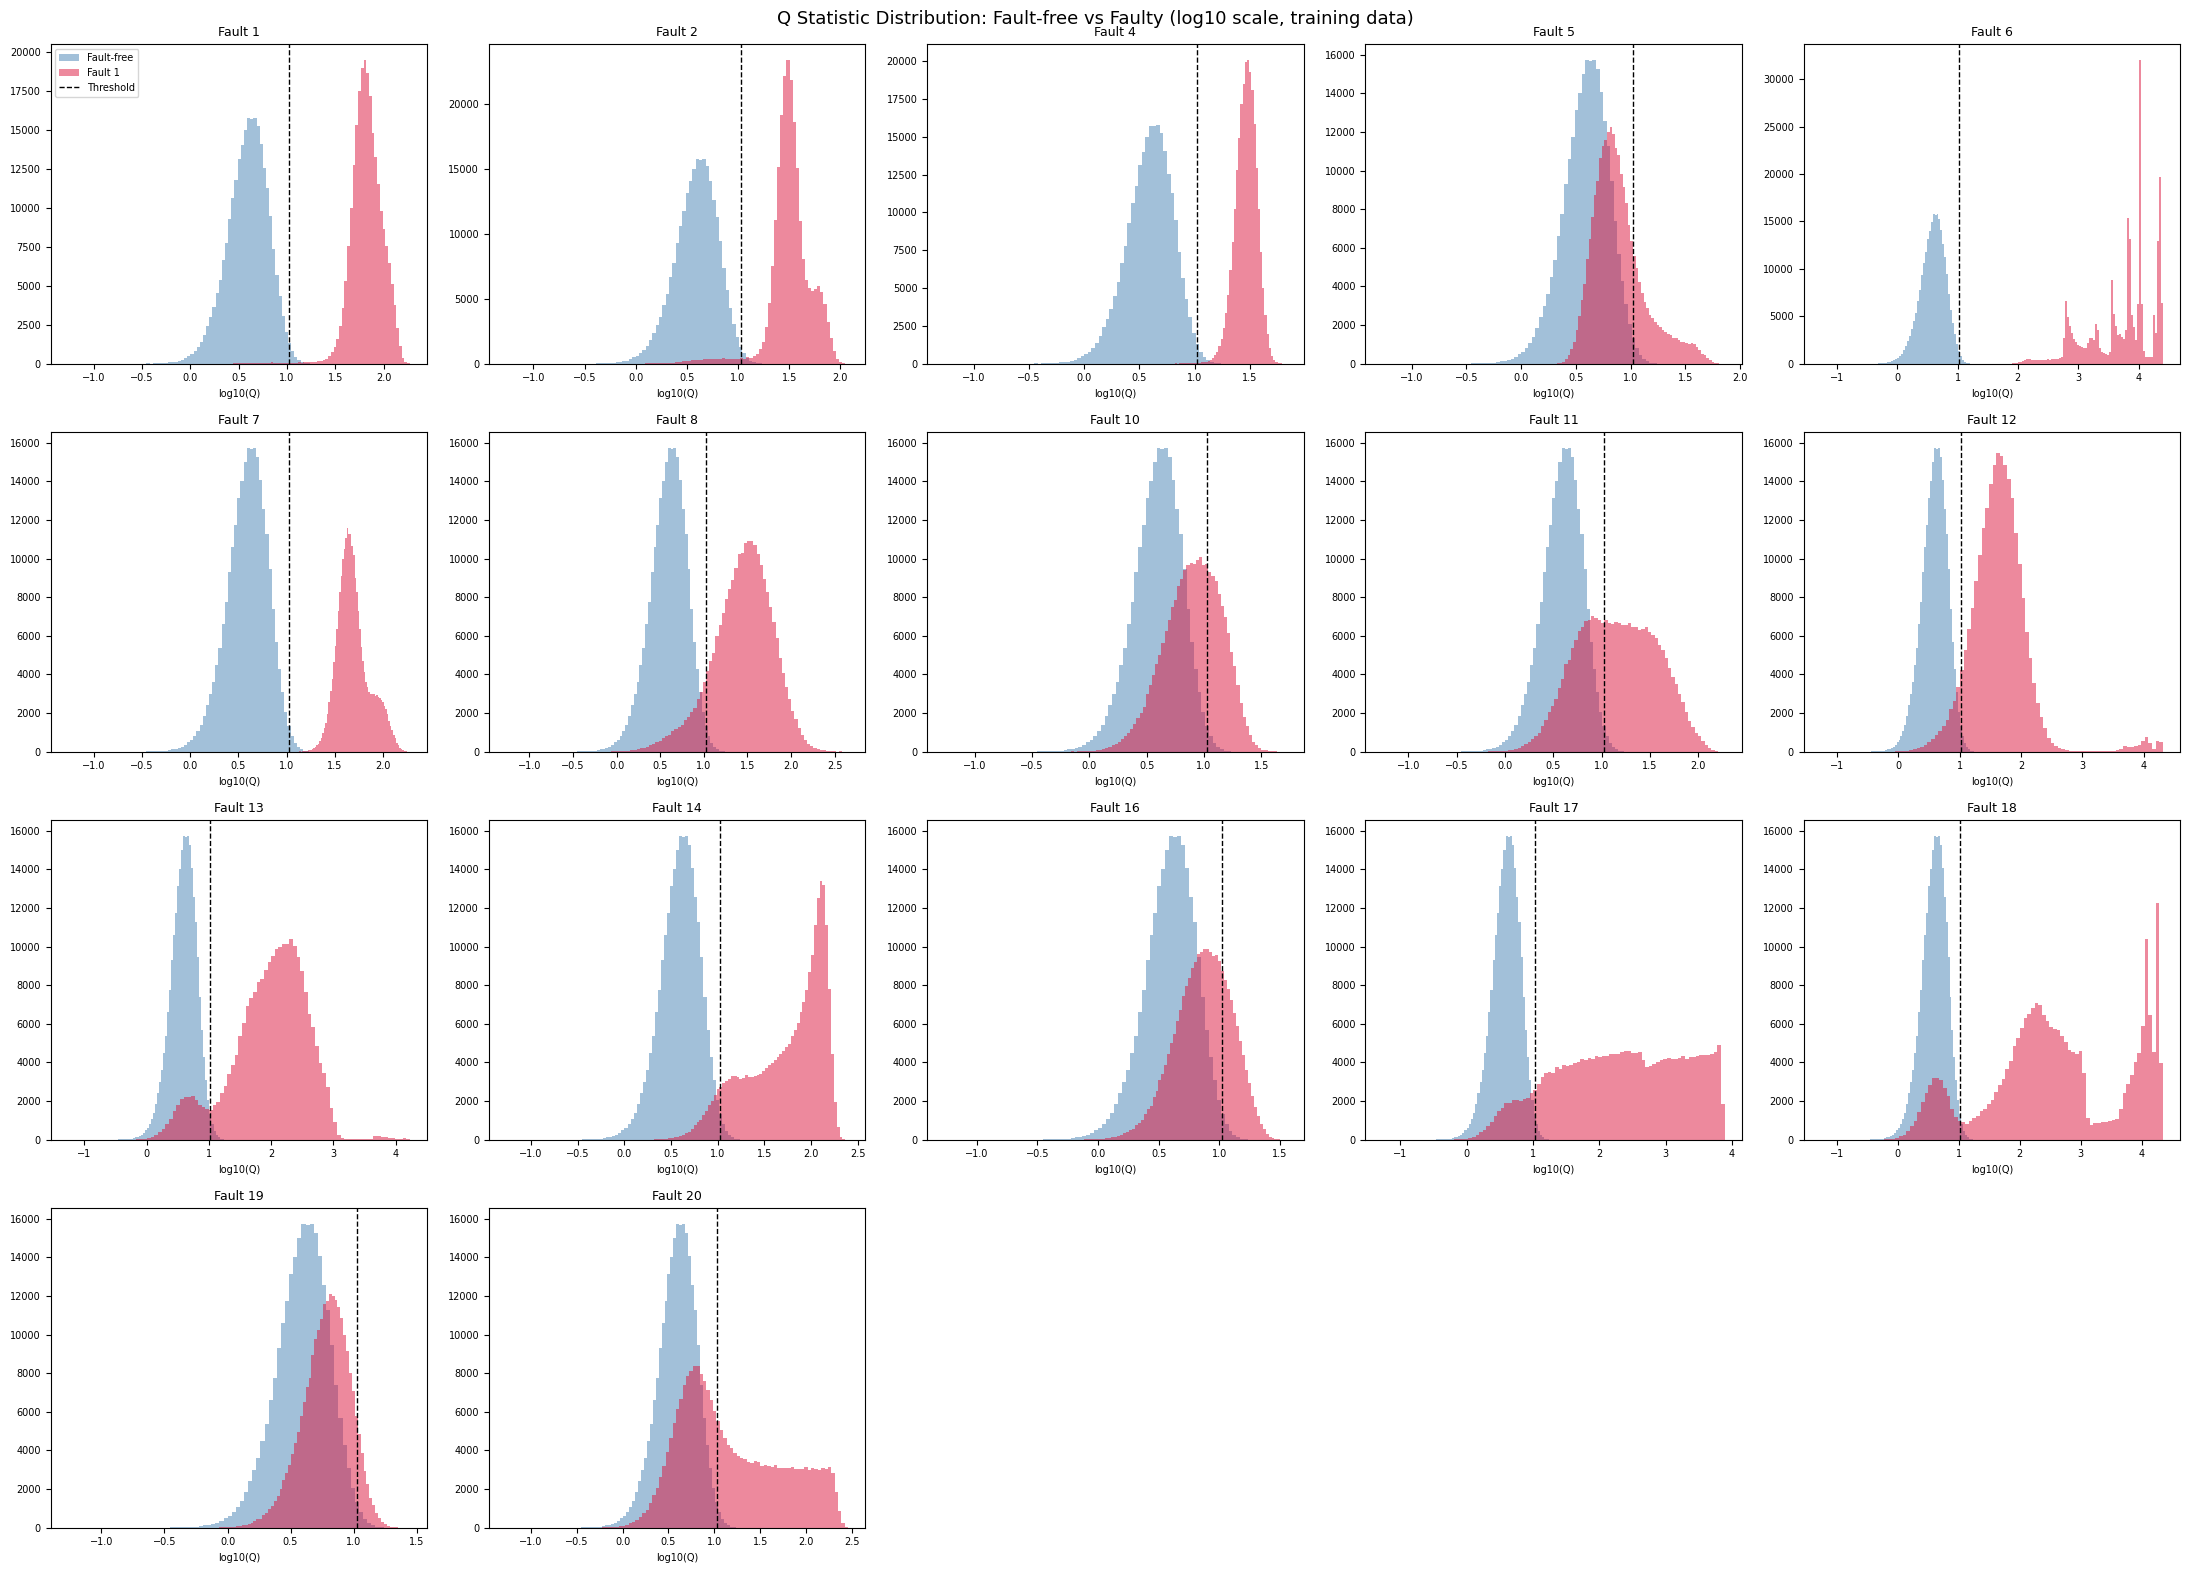

In [4]:
fault_numbers = [f for f in sorted(train_df["faultNumber"].unique()) if f != 0]

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for idx, fn in enumerate(fault_numbers):
    ax = axes[idx]
    faulty = train_df[train_df["faultNumber"] == fn][feature_cols].values
    _, Q_faulty = compute_stats(faulty, P, L)
    ax.hist(np.log10(Q_ff + 1e-6),     bins=80, alpha=0.5, color="steelblue", label="Fault-free")
    ax.hist(np.log10(Q_faulty + 1e-6), bins=80, alpha=0.5, color="crimson",   label=f"Fault {fn}")
    ax.axvline(np.log10(Q_thresh_stat), color="black", linestyle="--", linewidth=1, label="Threshold")
    ax.set_title(f"Fault {fn}", fontsize=9)
    ax.set_xlabel("log10(Q)", fontsize=7)
    ax.tick_params(labelsize=7)
    if idx == 0:
        ax.legend(fontsize=7)

for j in range(len(fault_numbers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Q Statistic Distribution: Fault-free vs Faulty (log10 scale, training data)", fontsize=13)
plt.tight_layout()
plt.show()

### Findings

Each plot shows the log10(Q) distribution for fault-free samples (blue) and faulty samples (red), with the Jackson-Mudholkar threshold as a dashed line. The further the red distribution sits to the right of the threshold, the more detectable the fault is.

**Strong separation** -- faulty distribution is almost entirely to the right of the threshold, minimal overlap with fault-free:
- **Faults 1, 4, 6, 7, 14** -- the red histogram barely overlaps with blue. These faults produce reconstruction errors well above the threshold and are expected to be detected reliably.

**Moderate separation** -- faulty distribution is shifted right but with noticeable overlap near the threshold:
- **Faults 2, 8, 12, 13, 17, 18** -- a clear rightward shift but a portion of the faulty samples fall near or below the threshold. Detection is expected to be good but not perfect.

**Weak separation** -- faulty and fault-free distributions overlap heavily, making detection difficult:
- **Fault 11, 20** -- the faulty distribution is bimodal or spread out, with a significant portion on the fault-free side of the threshold.
- **Faults 5, 10, 16, 19** -- the red distribution largely overlaps with the blue. The fault signal in Q is too weak for reliable detection. These faults are the hardest cases for PCA-based detection.

**Overall pattern:**
- 5 faults show strong separability, 6 moderate, and 6 weak -- consistent with known TEP benchmark results where roughly one-third of faults are inherently difficult for linear PCA.
- The log scale reveals that even for weakly-separated faults, the faulty distribution has a heavier right tail, meaning some samples do cross the threshold -- just not reliably.
- Faults 3, 9, and 15 are excluded -- their Q distributions are nearly identical to fault-free, confirming they are undetectable by PCA.

## Section 5 - Control Charts (Time Series)

One representative test run per fault is plotted as a time series. The x-axis is sample number (0--960), the y-axis is the statistic value on a log scale. The green dotted vertical line marks fault onset at sample 160.

- **Blue line:** Q statistic (faint = raw, solid = smoothed with rolling mean window=5 for visual clarity)
- **Orange line:** T² statistic (raw)
- **Red dashed:** Q threshold (Jackson-Mudholkar, 99% confidence)
- **Steelblue dashed:** T² threshold (F-distribution, 99% confidence)

Note: smoothing is applied here **only for visual clarity** -- detection in Section 6 uses raw Q values compared directly against the threshold.

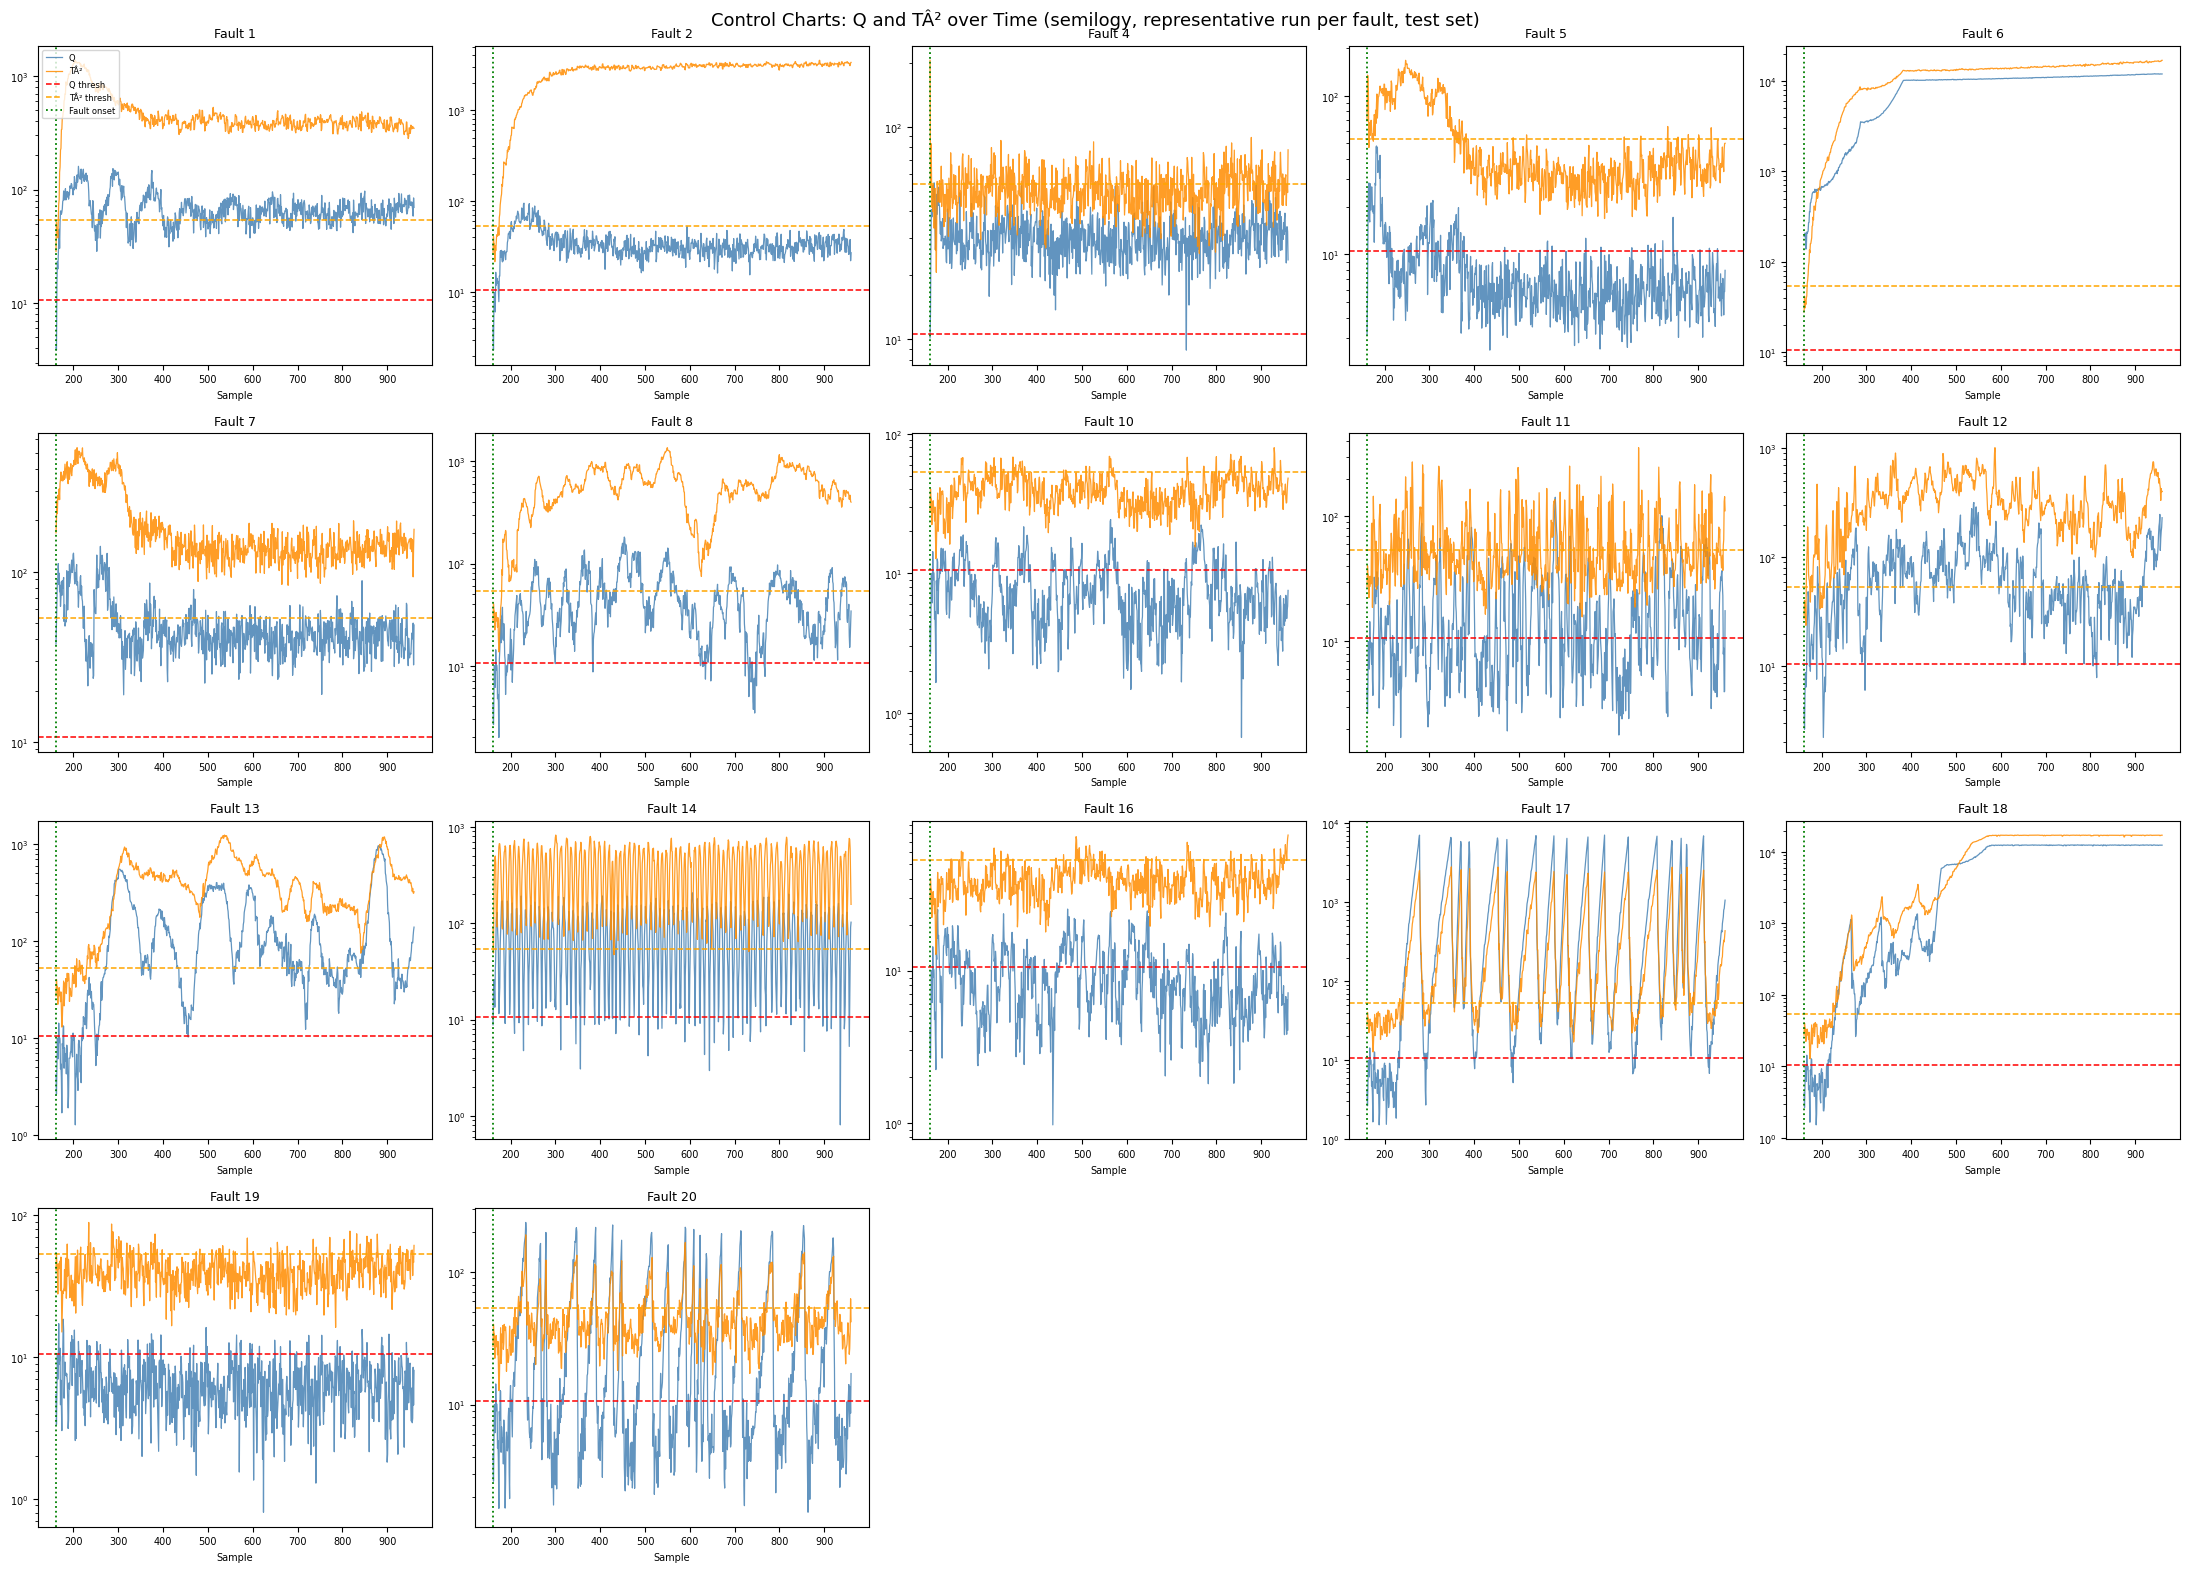

In [5]:
fault_numbers = [f for f in sorted(test_df["faultNumber"].unique()) if f != 0]

fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for idx, fn in enumerate(fault_numbers):
    ax = axes[idx]

    fault_data = test_df[test_df["faultNumber"] == fn]
    first_run  = fault_data["run_id"].iloc[0]
    run_data   = fault_data[fault_data["run_id"] == first_run].sort_values("sample")

    X_run          = run_data[feature_cols].values
    T2_run, Q_run  = compute_stats(X_run, P, L)
    Q_smooth       = smooth(Q_run, window=5)
    samples        = run_data["sample"].values

    ax.semilogy(samples, Q_run    + 1e-10, color="steelblue", linewidth=0.7, alpha=0.4, label="Q (raw)")
    ax.semilogy(samples, Q_smooth + 1e-10, color="steelblue", linewidth=1.2, alpha=0.9, label="Q (smoothed)")
    ax.semilogy(samples, T2_run   + 1e-10, color="darkorange", linewidth=0.9, alpha=0.85, label="TÂ²")
    ax.axhline(Q_thresh_stat,  color="red",       linestyle="--", linewidth=1.1, label="Q thresh")
    ax.axhline(T2_thresh_stat, color="steelblue", linestyle="--", linewidth=1.1, label="TÂ² thresh")
    ax.axvline(160, color="green", linestyle=":", linewidth=1.3, label="Fault onset")

    ax.set_title(f"Fault {fn}", fontsize=9)
    ax.set_xlabel("Sample", fontsize=7)
    ax.tick_params(labelsize=7)

    if idx == 0:
        ax.legend(fontsize=6, loc="upper left")

for j in range(len(fault_numbers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Control Charts: Q and TÂ² over Time (semilogy, representative run per fault, test set)", fontsize=13)
plt.tight_layout()
plt.show()

### Findings

Each plot shows Q (blue) and T² (orange) over time on a log scale. The red dashed line is the Q threshold, the steelblue dashed line is the T² threshold, and the green dotted vertical line marks fault onset at sample 160. Pre-onset samples should stay below threshold; post-onset samples should cross it.

**Sustained detection** -- both or either statistic cross their threshold after onset and stay elevated:
- **Faults 1, 2, 6, 7, 12, 13, 17, 18** -- Q and/or T² rise clearly after onset and remain above threshold for the rest of the run. These faults are consistently detectable.
- **Fault 4** -- T² shoots up immediately after onset and stays well above its threshold. Very strong, immediate detection.

**Moderate detection** -- clear signal but with some dips below threshold:
- **Faults 8, 11** -- statistics rise after onset but oscillate, spending most time above threshold with occasional drops below.

**Intermittent detection** -- statistics cross and fall below threshold repeatedly:
- **Faults 10, 16, 20** -- both Q and T² oscillate around their thresholds without sustained elevation. Detection happens in bursts, which explains the lower FDR values for these faults in Section 6.

**Poor detection** -- signals remain mostly below threshold even after onset:
- **Faults 5, 19** -- Q and T² stay near or below their thresholds after fault onset. The fault produces little signal that PCA can distinguish from normal variation.

**Fault 14 -- unique pattern:**
- Q (blue) dominates and reaches extremely high values. This fault (reactor cooling water valve sticking) causes a large sustained reconstruction error, meaning the fault signal lies almost entirely outside the PCA subspace. Q is the primary detector here.

**T² vs Q:**
- Both statistics contribute under the OR rule -- a sample is flagged if either exceeds its threshold.
- T² captures faults that amplify variation within the normal PCA directions. Q captures faults that introduce variation the PCA model cannot explain.
- Which statistic dominates depends on where the fault signal lands relative to the PCA subspace.

## Section 6 - Per-fault Evaluation

Evaluate PCA fault detection on the held-out **test set** across all **17 fault classes** (faults 3, 9, 15 excluded). A sample is flagged as faulty if **Q > Q_threshold OR T² > T²_threshold**.

**Detection methodology:**
- T² and Q statistics are computed per sample using the fitted PCA model (raw values, no smoothing)
- A sample is flagged if Q exceeds the Jackson-Mudholkar threshold OR T² exceeds the F-distribution threshold
- FDR is computed only on post-onset samples (sample > 160)

**Metrics:**
- **FDR** (Fault Detection Rate) = TP / (TP + FN) -- % of post-onset fault samples correctly flagged
- **F1** -- harmonic mean of precision and recall (fault-free test data used as negatives)
- **Accuracy** -- overall correct classifications
- **Global FPR** reported once above the table -- computed on all fault-free test samples

In [84]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

TEST_ONSET = 160

# Fault-free test data (used as negatives for all per-fault metrics)
ff_test = test_df[test_df['faultNumber'] == 0][feature_cols].values
T2_ff_test, Q_ff_test = compute_stats(ff_test, P, L)
ff_flagged  = (Q_ff_test > Q_thresh_stat) | (T2_ff_test > T2_thresh_stat)
global_fpr  = ff_flagged.mean()

# Fault 0 row
tn0 = int((~ff_flagged).sum())
fp0 = int(ff_flagged.sum())
results = [{
    'Fault': 0,
    'FDR (Recall)': float('nan'),
    'F1':           float('nan'),
    'Accuracy':     tn0 / (tn0 + fp0),
}]

cms = {}
total_tp, total_post_onset = 0, 0

for fn in sorted(test_df['faultNumber'].unique()):
    if fn == 0:
        continue
    fault_data = test_df[test_df['faultNumber'] == fn].copy()
    post_onset = (fault_data['sample'] > TEST_ONSET).values

    X_fault    = fault_data[feature_cols].values
    T2_f, Q_f  = compute_stats(X_fault, P, L)
    flagged_fault = (Q_f > Q_thresh_stat) | (T2_f > T2_thresh_stat)

    fdr = flagged_fault[post_onset].mean()

    # Combine fault-free (label=0) + post-onset fault (label=1) for proper F1/Accuracy
    y_true = np.concatenate([np.zeros(len(ff_flagged)), np.ones(post_onset.sum())])
    y_pred = np.concatenate([ff_flagged.astype(int), flagged_fault[post_onset].astype(int)])

    f1  = f1_score(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cms[fn] = cm

    results.append({
        'Fault': fn,
        'FDR (Recall)': fdr,
        'F1':           f1,
        'Accuracy':     acc,
    })
    total_tp         += int(flagged_fault[post_onset].sum())
    total_post_onset += int(post_onset.sum())

results_df = pd.DataFrame(results).set_index('Fault')
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'Global FPR on fault-free test data: {global_fpr:.4f} ({global_fpr*100:.2f}%)')
print(f'  True Negatives:  {tn0:,}')
print(f'  False Positives: {fp0:,}')
print()
print(results_df.to_string())
print()

fault_rows  = results_df.loc[1:]
mean_fdr    = fault_rows['FDR (Recall)'].mean()
mean_f1     = fault_rows['F1'].mean()
mean_acc    = fault_rows['Accuracy'].mean()
overall_fdr = total_tp / total_post_onset

print(f'Mean FDR:      {mean_fdr:.4f}')
print(f'Mean F1:       {mean_f1:.4f}')
print(f'Mean Accuracy: {mean_acc:.4f}')
print()
print(f'Overall FDR (all faults, all post-onset samples): {overall_fdr:.4f} ({overall_fdr*100:.2f}%)')
print(f'  Total post-onset samples: {total_post_onset:,}')
print(f'  Total detected:           {total_tp:,}')
print(f'  Total missed:             {total_post_onset - total_tp:,}')

Global FPR on fault-free test data: 0.0105 (1.05%)
  True Negatives:  474,965
  False Positives: 5,035

       FDR (Recall)     F1  Accuracy
Fault                               
0               NaN    NaN    0.9895
1            1.0000 0.9937    0.9943
2            0.9907 0.9891    0.9900
4            1.0000 0.9937    0.9943
5            0.2497 0.3956    0.6532
6            1.0000 0.9937    0.9943
7            1.0000 0.9937    0.9943
8            0.9762 0.9817    0.9835
10           0.4424 0.6081    0.7408
11           0.8158 0.8923    0.9105
12           0.9918 0.9896    0.9906
13           0.9509 0.9686    0.9720
14           1.0000 0.9937    0.9943
16           0.2891 0.4442    0.6711
17           0.9435 0.9647    0.9686
18           0.9411 0.9634    0.9675
19           0.1163 0.2060    0.5926
20           0.5666 0.7176    0.7973

Mean FDR:      0.7808
Mean F1:       0.8288
Mean Accuracy: 0.8947

Overall FDR (all faults, all post-onset samples): 0.7808 (78.08%)
  Total post-onset sam

### Findings

**Global false alarm rate: 1.05%** (474,965 true negatives, 5,035 false positives on fault-free test data) -- closely matches the 99% confidence design target, confirming the thresholds are well-calibrated on unseen data.

**Per-fault results:**

| Category | Faults | FDR |
|----------|--------|-----|
| Perfect detection | 1, 4, 6, 7, 14 | 100% |
| High detection | 2, 8, 12, 13, 17, 18 | 94% -- 99% |
| Moderate detection | 11, 20 | 57% -- 82% |
| Low detection | 5, 10, 16 | 25% -- 44% |
| Very low detection | 19 | 12% |

**Overall performance (17 fault classes):**
- Mean FDR: **78.08%** -- across all 6.8M post-onset test samples, 78% were correctly flagged
- Mean F1: **82.88%**
- Mean Accuracy: **89.47%**

**Why the hard faults are hard:**
- **Fault 19 (12%) and Fault 5 (25%)** -- the process signatures of these faults are too similar to normal operation. Their Q and T² values barely rise above the fault-free level, as seen in both the distribution histograms (Section 4) and control charts (Section 5). These are fundamental limitations of linear PCA, not a calibration issue.
- **Faults 10 (44%) and 16 (29%)** -- intermittent faults that oscillate around the detection threshold. The control charts (Section 5) show both statistics bouncing above and below threshold rather than staying elevated, resulting in detection only during the peaks.
- **Fault 20 (57%)** -- oscillatory nature means detection is periodic rather than sustained.

**Results are consistent with earlier sections:**
- All 5 faults categorized as "strong separation" in Section 4 (1, 4, 6, 7, 14) achieve 100% FDR here.
- All 6 faults categorized as "weak separation" in Section 4 (5, 10, 11, 16, 19, 20) fall in the moderate-to-very-low FDR range here.
- The control chart patterns in Section 5 (sustained vs. intermittent vs. near-threshold) directly predict which faults land in which category.

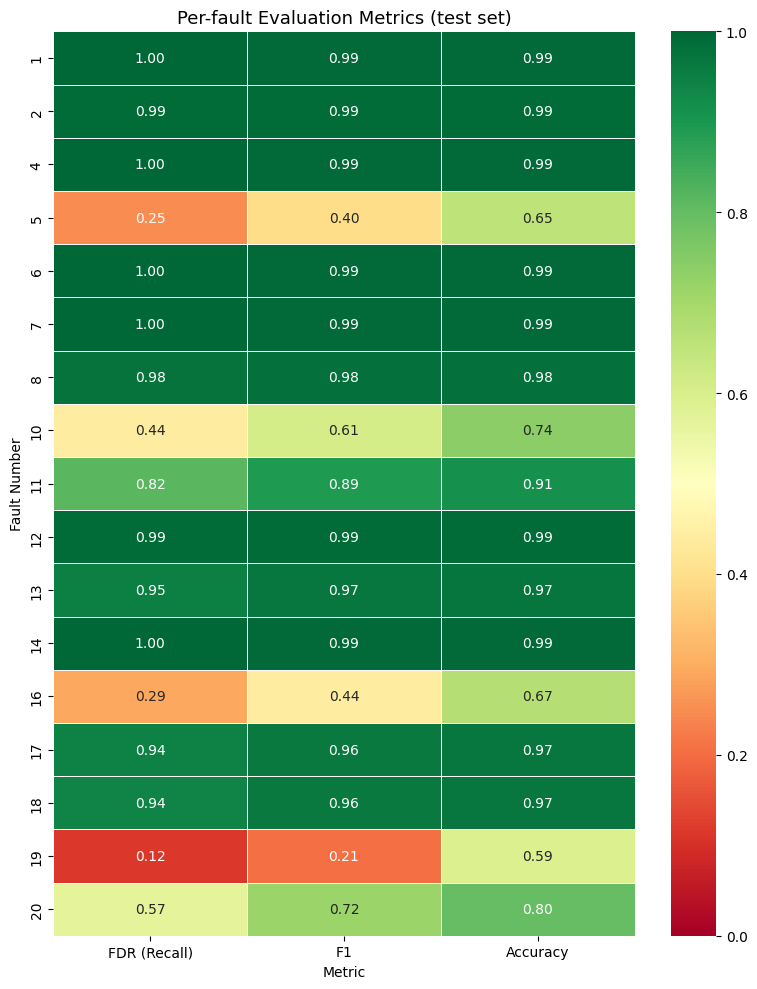

In [85]:
# Heatmap: FDR, F1, Accuracy per fault
metrics_to_plot = ["FDR (Recall)", "F1", "Accuracy"]
plot_data = results_df.loc[1:][metrics_to_plot]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    plot_data,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title("Per-fault Evaluation Metrics (test set)", fontsize=13)
ax.set_xlabel("Metric")
ax.set_ylabel("Fault Number")
plt.tight_layout()
plt.show()

In [86]:
for fn, cm in sorted(cms.items()):
    print(f"The Confusion Matrix for Fault {fn}:")
    print(cm)
    print()

The Confusion Matrix for Fault 1:
[[474965   5035]
 [    15 399985]]

The Confusion Matrix for Fault 2:
[[474965   5035]
 [  3721 396279]]

The Confusion Matrix for Fault 4:
[[474965   5035]
 [     0 400000]]

The Confusion Matrix for Fault 5:
[[474965   5035]
 [300125  99875]]

The Confusion Matrix for Fault 6:
[[474965   5035]
 [     0 400000]]

The Confusion Matrix for Fault 7:
[[474965   5035]
 [     0 400000]]

The Confusion Matrix for Fault 8:
[[474965   5035]
 [  9513 390487]]

The Confusion Matrix for Fault 10:
[[474965   5035]
 [223027 176973]]

The Confusion Matrix for Fault 11:
[[474965   5035]
 [ 73697 326303]]

The Confusion Matrix for Fault 12:
[[474965   5035]
 [  3279 396721]]

The Confusion Matrix for Fault 13:
[[474965   5035]
 [ 19629 380371]]

The Confusion Matrix for Fault 14:
[[474965   5035]
 [     1 399999]]

The Confusion Matrix for Fault 16:
[[474965   5035]
 [284373 115627]]

The Confusion Matrix for Fault 17:
[[474965   5035]
 [ 22619 377381]]

The Confusion

## Section 7 - Contribution Heatmap

For each fault, the per-variable contribution to SPE (Q) is computed as:

`contribution[var] = |x[var] * (x[var] - x_reconstructed[var])|`

Averaged over all post-onset samples that were correctly detected (TP samples), this shows which features are most responsible for driving the reconstruction error during each fault. High contribution indicates the variable behaves anomalously relative to the normal PCA subspace.

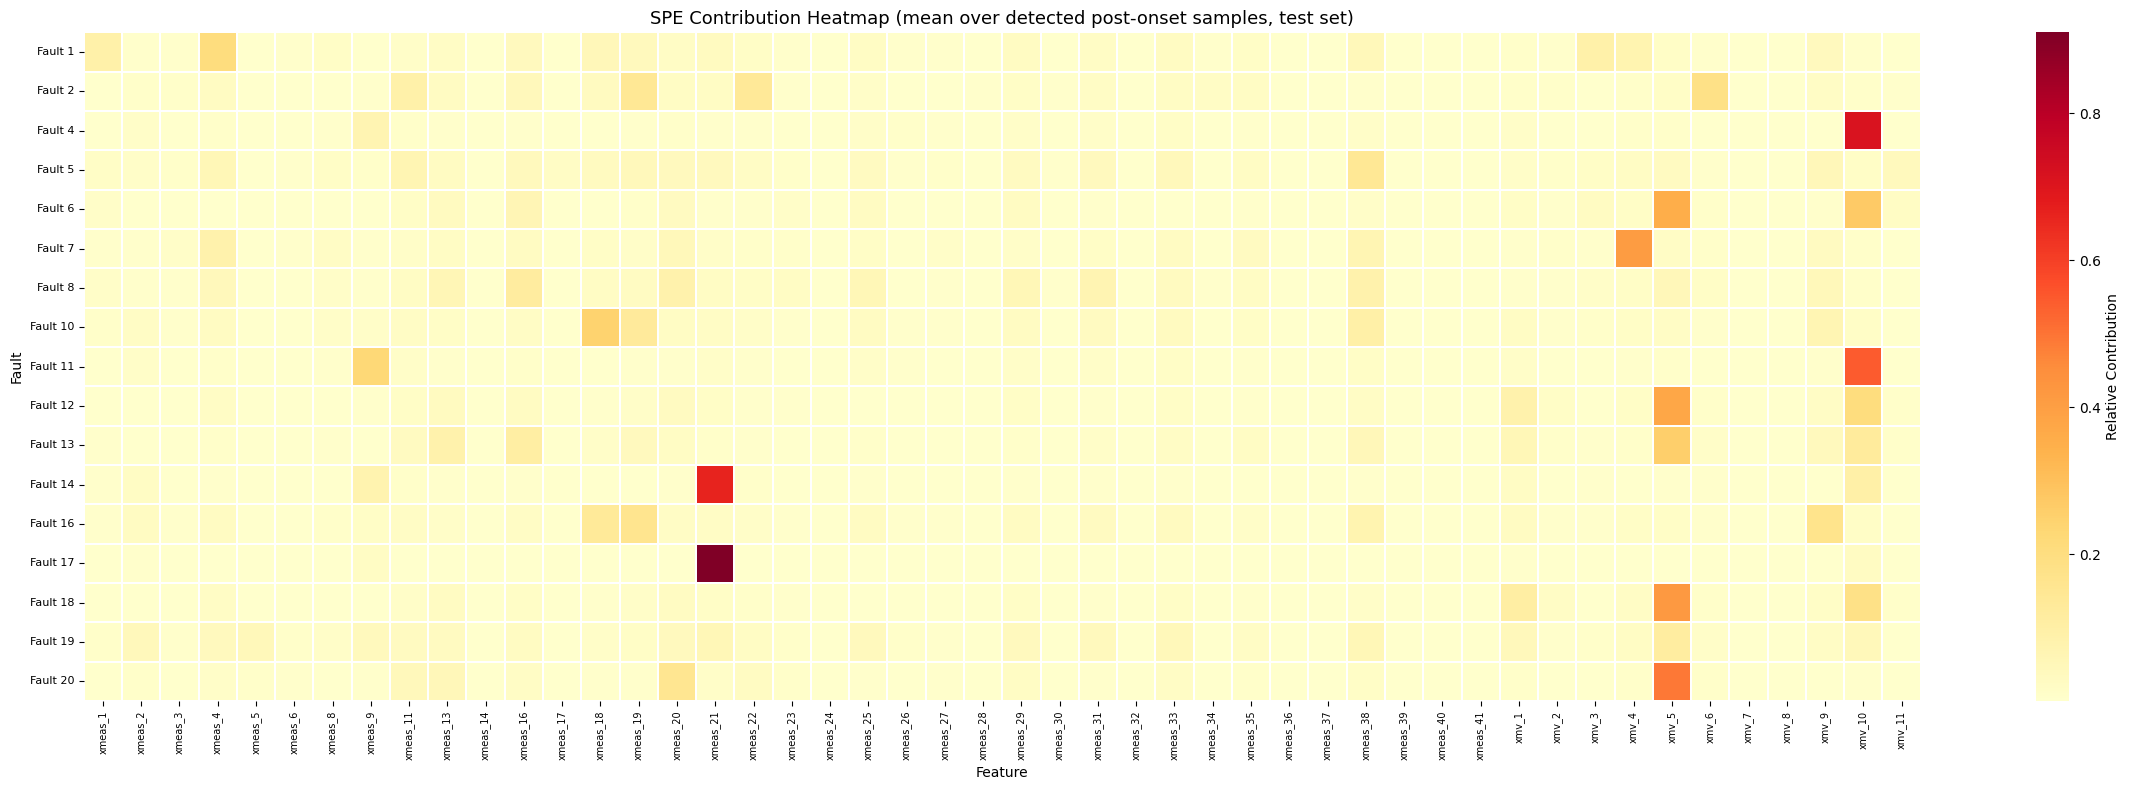

In [87]:
def compute_contributions(X, P):
    """Per-variable SPE contribution: |x * (x - x_reconstructed)|"""
    T      = X @ P
    X_recon = T @ P.T
    return np.abs(X * (X - X_recon))

TEST_ONSET = 160
fault_numbers = [f for f in sorted(test_df["faultNumber"].unique()) if f != 0]

# Compute mean contribution per fault over detected post-onset samples
contrib_matrix = np.zeros((len(fault_numbers), len(feature_cols)))

for i, fn in enumerate(fault_numbers):
    fault_data = test_df[test_df["faultNumber"] == fn].copy()
    post_onset = (fault_data["sample"] > TEST_ONSET).values
    X_fault    = fault_data[feature_cols].values
    T2_f, Q_f  = compute_stats(X_fault, P, L)
    flagged    = (Q_f > Q_thresh_stat) | (T2_f > T2_thresh_stat)
    tp_mask    = post_onset & flagged
    if tp_mask.sum() > 0:
        contribs = compute_contributions(X_fault[tp_mask], P)
        contrib_matrix[i] = contribs.mean(axis=0)

# Normalize each fault row so contributions sum to 1 (relative importance)
contrib_norm = contrib_matrix / (contrib_matrix.sum(axis=1, keepdims=True) + 1e-10)

contrib_df = pd.DataFrame(
    contrib_norm,
    index=[f"Fault {fn}" for fn in fault_numbers],
    columns=feature_cols
)

fig, ax = plt.subplots(figsize=(24, 8))
sns.heatmap(
    contrib_df,
    cmap="YlOrRd", linewidths=0.2,
    ax=ax, cbar_kws={"label": "Relative Contribution"}
)
ax.set_title("SPE Contribution Heatmap (mean over detected post-onset samples, test set)", fontsize=13)
ax.set_xlabel("Feature")
ax.set_ylabel("Fault")
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

### Findings

The heatmap shows normalized per-variable SPE contribution averaged over correctly detected post-onset test samples. Each row sums to 1 -- darker cells indicate which features drive the reconstruction error most strongly for that fault.

**Dominant single-feature faults:**
- **Fault 17** -- xmeas_20 (Compressor Work) is overwhelmingly dominant -- the darkest cell in the entire heatmap. Nearly all reconstruction error traces to a single variable.
- **Fault 14** -- xmeas_21 (Reactor Cooling Water Outlet Temperature) dominates. Physically consistent with Fault 14 being reactor cooling water valve sticking -- valve stiction directly shows up in the outlet temperature reading.
- **Fault 4** -- xmv_10 (Reactor Cooling Water Flow) dominates. Fault 4 is a step change in reactor cooling water inlet temperature; the flow control response captures this shift.
- **Fault 11** -- xmeas_9 (Reactor Temperature) is the primary contributor, consistent with Fault 11 being random variation in reactor cooling water inlet temperature propagating to the reactor.

**Multi-feature faults (spread contribution):**
- **Faults 6, 7, 12, 18, 20** -- contributions are elevated across xmv variables (xmv_4, xmv_5 region), suggesting these faults activate the process control loops and cause multiple manipulated variables to respond simultaneously.
- **Fault 10** -- xmeas_18 and xmeas_19 (Stripper Temperature and Steam Flow) show elevated contributions alongside other features. Fault 10 is C feed temperature random variation, which propagates broadly through the stripper section.

**Sparse overall structure:**
- Most faults show 1--3 dominant features with near-zero contributions elsewhere. This sparsity confirms PCA is capturing fault-specific anomalies rather than distributing reconstruction error uniformly across all variables.
- Features with consistently low contribution across all faults (light yellow entire column) contribute little to fault detection and are candidates for further feature reduction in future work.